In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr  # para correlaciones de perfiles

# Carga del dataset base
df_all = pd.read_parquet("df_all_procesado.parquet")

df_all.head(), df_all.columns


(      pickup_datetime    dropOff_datetime  PUlocationID  DOlocationID
 0 2025-01-01 00:01:53 2025-01-01 00:32:39         163.0         148.0
 1 2025-01-01 00:04:13 2025-01-01 00:17:52          88.0         246.0
 2 2025-01-01 00:06:38 2025-01-01 00:16:20         153.0          74.0
 3 2025-01-01 00:07:28 2025-01-01 00:20:58         166.0          74.0
 4 2025-01-01 00:08:00 2025-01-01 00:28:00         141.0         113.0,
 Index(['pickup_datetime', 'dropOff_datetime', 'PUlocationID', 'DOlocationID'], dtype='object'))

In [57]:
# Asegurar tipo datetime
df_all["pickup_datetime"] = pd.to_datetime(df_all["pickup_datetime"])

# Componentes de tiempo básicos
df_all["date"]    = df_all["pickup_datetime"].dt.date
df_all["weekday"] = df_all["pickup_datetime"].dt.weekday   # 0=lun,...,6=dom
df_all["hour"]    = df_all["pickup_datetime"].dt.hour
df_all["minute"]  = df_all["pickup_datetime"].dt.minute

# Bucket de 15 minutos: 24h * 4 = 96 buckets
df_all["bucket15"] = df_all["hour"] * 4 + (df_all["minute"] // 15)

df_all[["pickup_datetime", "date", "weekday", "hour", "minute", "bucket15"]].head()


,pickup_datetime,date,weekday,hour,minute,bucket15
0,2025-01-01 00:01:53,2025-01-01,2,0,1,0
1,2025-01-01 00:04:13,2025-01-01,2,0,4,0
2,2025-01-01 00:06:38,2025-01-01,2,0,6,0
3,2025-01-01 00:07:28,2025-01-01,2,0,7,0
4,2025-01-01 00:08:00,2025-01-01,2,0,8,0


In [58]:
# Número de viajes por día, weekday y bucket15
demand_15 = (
    df_all
    .groupby(["date", "weekday", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

demand_15.head()


,date,weekday,bucket15,viajes
0,2025-01-01,2,0,11
1,2025-01-01,2,1,20
2,2025-01-01,2,2,12
3,2025-01-01,2,3,11
4,2025-01-01,2,4,20


In [59]:
daily_profiles = demand_15.pivot_table(
    index=["date", "weekday"],
    columns="bucket15",
    values="viajes",
    fill_value=0
)

bucket_cols = daily_profiles.columns.tolist()
daily_profiles.head()


,bucket15,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
date,weekday,,,,,,,,,,,,,,,,,,,,,
2025-01-01,2,11.0,20.0,12.0,11.0,20.0,17.0,18.0,15.0,11.0,19.0,...,14.0,9.0,12.0,10.0,12.0,6.0,6.0,6.0,6.0,1.0
2025-01-02,3,6.0,3.0,2.0,3.0,3.0,1.0,3.0,0.0,2.0,0.0,...,24.0,28.0,22.0,17.0,20.0,13.0,18.0,16.0,17.0,11.0
2025-01-03,4,7.0,11.0,5.0,5.0,7.0,6.0,5.0,4.0,6.0,5.0,...,24.0,34.0,22.0,31.0,26.0,24.0,16.0,20.0,21.0,13.0
2025-01-04,5,8.0,15.0,15.0,8.0,8.0,7.0,6.0,11.0,3.0,4.0,...,33.0,35.0,33.0,20.0,29.0,24.0,26.0,24.0,12.0,13.0
2025-01-05,6,9.0,15.0,12.0,14.0,8.0,17.0,5.0,7.0,7.0,8.0,...,15.0,17.0,22.0,10.0,7.0,11.0,8.0,7.0,7.0,4.0


In [60]:
daily_totals = daily_profiles.sum(axis=1)
daily_totals_df = daily_totals.reset_index(name="total_viajes")
daily_totals_df.head()


,date,weekday,total_viajes
0,2025-01-01,2,764.0
1,2025-01-02,3,1412.0
2,2025-01-03,4,1723.0
3,2025-01-04,5,1715.0
4,2025-01-05,6,1431.0


In [61]:
daily_shapes = daily_profiles.div(daily_totals, axis=0)
daily_shapes_df = daily_shapes.reset_index()
daily_shapes_df.head()


bucket15,date,weekday,0,1,2,3,4,5,6,7,...,86,87,88,89,90,91,92,93,94,95
0,2025-01-01,2,0.014398,0.026178,0.015707,0.014398,0.026178,0.022251,0.023560,0.019634,...,0.018325,0.011780,0.015707,0.013089,0.015707,0.007853,0.007853,0.007853,0.007853,0.001309
1,2025-01-02,3,0.004249,0.002125,0.001416,0.002125,0.002125,0.000708,0.002125,0.000000,...,0.016997,0.019830,0.015581,0.012040,0.014164,0.009207,0.012748,0.011331,0.012040,0.007790
2,2025-01-03,4,0.004063,0.006384,0.002902,0.002902,0.004063,0.003482,0.002902,0.002322,...,0.013929,0.019733,0.012768,0.017992,0.015090,0.013929,0.009286,0.011608,0.012188,0.007545
3,2025-01-04,5,0.004665,0.008746,0.008746,0.004665,0.004665,0.004082,0.003499,0.006414,...,0.019242,0.020408,0.019242,0.011662,0.016910,0.013994,0.015160,0.013994,0.006997,0.007580
4,2025-01-05,6,0.006289,0.010482,0.008386,0.009783,0.005590,0.011880,0.003494,0.004892,...,0.010482,0.011880,0.015374,0.006988,0.004892,0.007687,0.005590,0.004892,0.004892,0.002795


In [62]:
def marcar_outliers_totales(df_tot: pd.DataFrame, k: float = 2.5):
    df_tot = df_tot.copy()
    df_tot["outlier_total"] = False

    for w in range(7):
        mask = df_tot["weekday"] == w
        datos_w = df_tot.loc[mask, "total_viajes"]

        # si hay muy pocos días de ese weekday, no marcamos nada
        if len(datos_w) < 10:
            continue

        q1 = datos_w.quantile(0.25)
        q3 = datos_w.quantile(0.75)
        iqr = q3 - q1

        low  = q1 - k * iqr
        high = q3 + k * iqr

        df_tot.loc[mask & ((df_tot["total_viajes"] < low) | (df_tot["total_viajes"] > high)), "outlier_total"] = True

    return df_tot

daily_totals_df = marcar_outliers_totales(daily_totals_df, k=2.5)
daily_totals_df["outlier_total"].value_counts()


,count
outlier_total,
False,161
True,20


In [63]:
bucket_cols = [c for c in daily_shapes_df.columns if isinstance(c, int)]

weekday_shapes = (
    daily_shapes_df
    .groupby("weekday")[bucket_cols]
    .mean()
)
weekday_shapes.head()


bucket15,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
weekday,,,,,,,,,,,,,,,,,,,,,
0,0.002962,0.002150,0.001732,0.001222,0.001085,0.001010,0.000580,0.000964,0.000927,0.000754,...,0.008880,0.008849,0.008951,0.006670,0.004940,0.004449,0.004208,0.003404,0.002964,0.002690
1,0.002604,0.001687,0.001863,0.001206,0.000890,0.001000,0.001253,0.000846,0.001104,0.000862,...,0.013747,0.012247,0.010526,0.009013,0.007068,0.006071,0.006004,0.005058,0.003631,0.003398
2,0.003716,0.004049,0.003535,0.002193,0.002351,0.001747,0.002070,0.001649,0.001354,0.001758,...,0.012839,0.010881,0.012133,0.009286,0.007247,0.007254,0.005803,0.004293,0.003222,0.002900
3,0.003572,0.002867,0.002509,0.001320,0.001100,0.000980,0.001236,0.000942,0.000874,0.000643,...,0.014360,0.013488,0.012182,0.010512,0.008668,0.006918,0.005782,0.005109,0.005406,0.004292
4,0.005109,0.003673,0.003519,0.002316,0.001895,0.001650,0.001543,0.001759,0.001484,0.000996,...,0.014745,0.015122,0.013068,0.012164,0.011310,0.009623,0.008945,0.009162,0.007104,0.006904


In [64]:
def calcular_corr_shape(daily_shapes_df, weekday_shapes):
    res = []
    for _, row in daily_shapes_df.iterrows():
        w = row["weekday"]
        shape_dia = row[bucket_cols].values.astype(float)
        shape_ref = weekday_shapes.loc[w].values.astype(float)

        # si un día tiene total casi cero, la forma no es muy informativa
        if shape_dia.sum() == 0 or shape_ref.sum() == 0:
            corr = np.nan
        else:
            corr, _ = pearsonr(shape_dia, shape_ref)
        res.append(corr)

    daily_shapes_df = daily_shapes_df.copy()
    daily_shapes_df["corr_shape_weekday"] = res
    return daily_shapes_df

daily_shapes_df = calcular_corr_shape(daily_shapes_df, weekday_shapes)
daily_shapes_df[["date", "weekday", "corr_shape_weekday"]].head()


bucket15,date,weekday,corr_shape_weekday
0,2025-01-01,2,-0.076231
1,2025-01-02,3,0.845362
2,2025-01-03,4,0.885743
3,2025-01-04,5,0.932555
4,2025-01-05,6,0.881339


In [65]:
umbral_corr = 0.85
daily_shapes_df["outlier_shape"] = daily_shapes_df["corr_shape_weekday"] < umbral_corr
daily_shapes_df["outlier_shape"].value_counts(dropna=False)


,count
outlier_shape,
False,125
True,56


In [66]:
hol = daily_totals_df.merge(
    daily_shapes_df[["date", "weekday", "corr_shape_weekday", "outlier_shape"]],
    on=["date", "weekday"],
    how="left"
)

hol["is_holiday_like"] = hol["outlier_total"] | hol["outlier_shape"]

hol[["date", "weekday", "total_viajes", "outlier_total", "corr_shape_weekday", "outlier_shape", "is_holiday_like"]].head()


,date,weekday,total_viajes,outlier_total,corr_shape_weekday,outlier_shape,is_holiday_like
0,2025-01-01,2,764.0,False,-0.076231,True,True
1,2025-01-02,3,1412.0,False,0.845362,True,True
2,2025-01-03,4,1723.0,False,0.885743,False,False
3,2025-01-04,5,1715.0,False,0.932555,False,False
4,2025-01-05,6,1431.0,False,0.881339,False,False


In [67]:
holiday_map = hol.set_index("date")["is_holiday_like"].to_dict()

df_all["is_holiday_like"] = df_all["date"].map(holiday_map)

df_normal = df_all[~df_all["is_holiday_like"].fillna(False)].copy()

print("Viajes totales (df original):", len(df_all))
print("Viajes totales (df_normal):", len(df_normal))

print("\nDías únicos (df):", df_all["date"].nunique())
print("Días únicos (df_normal):", df_normal["date"].nunique())

dias_drop = df_all["date"].nunique() - df_normal["date"].nunique()
print("\nDías eliminados:", dias_drop)
print("Proporción días eliminados:", dias_drop / df_all["date"].nunique())


Viajes totales (df original): 260838
Viajes totales (df_normal): 207959

Días únicos (df): 181
Días únicos (df_normal): 125

Días eliminados: 56
Proporción días eliminados: 0.30939226519337015


In [68]:
df_normal["pickup_datetime"] = pd.to_datetime(df_normal["pickup_datetime"])
df_normal["date"]    = df_normal["pickup_datetime"].dt.date
df_normal["weekday"] = df_normal["pickup_datetime"].dt.weekday
df_normal["hour"]    = df_normal["pickup_datetime"].dt.hour
df_normal["minute"]  = df_normal["pickup_datetime"].dt.minute
df_normal["bucket15"] = df_normal["hour"] * 4 + (df_normal["minute"] // 15)

demand_15_norm = (
    df_normal
    .groupby(["date", "weekday", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

daily_profiles_norm = demand_15_norm.pivot_table(
    index=["date", "weekday"],
    columns="bucket15",
    values="viajes",
    fill_value=0
)

bucket_cols = daily_profiles_norm.columns.tolist()
daily_profiles_norm.head()


,bucket15,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
date,weekday,,,,,,,,,,,,,,,,,,,,,
2025-01-03,4,7.0,11.0,5.0,5.0,7.0,6.0,5.0,4.0,6.0,5.0,...,24.0,34.0,22.0,31.0,26.0,24.0,16.0,20.0,21.0,13.0
2025-01-04,5,8.0,15.0,15.0,8.0,8.0,7.0,6.0,11.0,3.0,4.0,...,33.0,35.0,33.0,20.0,29.0,24.0,26.0,24.0,12.0,13.0
2025-01-05,6,9.0,15.0,12.0,14.0,8.0,17.0,5.0,7.0,7.0,8.0,...,15.0,17.0,22.0,10.0,7.0,11.0,8.0,7.0,7.0,4.0
2025-01-06,0,1.0,6.0,0.0,0.0,4.0,3.0,4.0,1.0,0.0,3.0,...,21.0,20.0,12.0,21.0,10.0,11.0,10.0,5.0,8.0,3.0
2025-01-07,1,11.0,2.0,3.0,3.0,2.0,4.0,7.0,4.0,4.0,1.0,...,25.0,36.0,25.0,25.0,15.0,18.0,15.0,12.0,4.0,4.0


In [69]:
daily_totals_norm = daily_profiles_norm.sum(axis=1)
daily_shapes_norm = daily_profiles_norm.div(daily_totals_norm, axis=0)

daily_shapes_norm_df = daily_shapes_norm.reset_index()
daily_totals_norm_df = daily_totals_norm.reset_index(name="total_viajes")

bucket_cols = [c for c in daily_shapes_norm_df.columns if isinstance(c, int)]


In [70]:
daily_shapes_norm.sum(axis=1).describe()


,0
count,1.250000e+02
mean,1.000000e+00
std,3.754374e-16
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


In [71]:
weekday_shapes_norm = (
    daily_shapes_norm_df
    .groupby("weekday")[bucket_cols]
    .mean()
)

corr_weekdays = weekday_shapes_norm.T.corr()
corr_weekdays


weekday,0,1,2,3,4,5,6
weekday,,,,,,,
0,1.000000,0.966182,0.960567,0.953105,0.886328,0.626210,0.819718
1,0.966182,1.000000,0.990036,0.986647,0.939860,0.705921,0.803553
2,0.960567,0.990036,1.000000,0.989612,0.955426,0.740068,0.815867
3,0.953105,0.986647,0.989612,1.000000,0.962261,0.746028,0.810549
4,0.886328,0.939860,0.955426,0.962261,1.000000,0.871276,0.842398
5,0.626210,0.705921,0.740068,0.746028,0.871276,1.000000,0.842606
6,0.819718,0.803553,0.815867,0.810549,0.842398,0.842606,1.000000


In [72]:
grupo_weekday = {
    0: "LUN",       # lunes
    1: "MAR_JUE",   # martes
    2: "MAR_JUE",   # miércoles
    3: "MAR_JUE",   # jueves
    4: "VIERNES",   # viernes
    5: "SABADO",    # sábado
    6: "DOMINGO"    # domingo
}

df_normal["weekday"] = df_normal["pickup_datetime"].dt.weekday
df_normal["tipo_dia_fino"] = df_normal["weekday"].map(grupo_weekday)

df_normal[["pickup_datetime", "weekday", "tipo_dia_fino"]].head()


,pickup_datetime,weekday,tipo_dia_fino
2176,2025-01-03 00:00:56,4,VIERNES
2177,2025-01-03 00:03:36,4,VIERNES
2178,2025-01-03 00:05:17,4,VIERNES
2179,2025-01-03 00:08:43,4,VIERNES
2180,2025-01-03 00:12:42,4,VIERNES


In [73]:
demand_15_fino = (
    df_normal
    .groupby(["date", "weekday", "tipo_dia_fino", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

daily_profiles_fino = demand_15_fino.pivot_table(
    index=["date", "weekday", "tipo_dia_fino"],
    columns="bucket15",
    values="viajes",
    fill_value=0
)

bucket_cols = daily_profiles_fino.columns.tolist()

daily_totals_fino = daily_profiles_fino.sum(axis=1)
daily_shapes_fino = daily_profiles_fino.div(daily_totals_fino, axis=0)

daily_shapes_fino_df = daily_shapes_fino.reset_index()
daily_totals_fino_df = daily_totals_fino.reset_index(name="total_viajes")


In [74]:
shape_por_grupo = (
    daily_shapes_fino_df
    .groupby("tipo_dia_fino")[bucket_cols]
    .mean()
)

niveles_por_grupo = (
    daily_totals_fino_df
    .groupby("tipo_dia_fino")["total_viajes"]
    .apply(list)
)

shape_por_grupo
niveles_por_grupo


,total_viajes
tipo_dia_fino,
DOMINGO,"[1431.0, 1014.0, 936.0, 904.0, 1008.0, 1059.0,..."
LUN,"[1515.0, 1693.0, 1663.0, 1523.0, 1384.0, 612.0..."
MAR_JUE,"[1721.0, 1969.0, 1858.0, 1989.0, 1999.0, 1871...."
SABADO,"[1715.0, 2035.0, 2085.0, 2037.0, 1952.0, 1578...."
VIERNES,"[1723.0, 1859.0, 1997.0, 1858.0, 1691.0, 1875...."


In [75]:
lambda_15_fino = {}

for g in shape_por_grupo.index:
    shape_g = shape_por_grupo.loc[g].values.astype(float)   # p_{g,b}
    niveles_g = np.array(niveles_por_grupo[g], dtype=float) # totales diarios
    T_prom_g = niveles_g.mean()

    lambda_g = T_prom_g * shape_g   # λ_{g,b}
    lambda_15_fino[g] = lambda_g

def demanda_esperada_grupo(grupo: str) -> np.ndarray:
    return lambda_15_fino[grupo].astype(float)

for g, lambdas in lambda_15_fino.items():
    niveles_g = np.array(niveles_por_grupo[g], dtype=float)
    print(g, "-> len:", len(lambdas),
          "  sum(lambda):", lambdas.sum(),
          "  mean(total):", niveles_g.mean())


DOMINGO -> len: 96   sum(lambda): 1079.3   mean(total): 1079.3
LUN -> len: 96   sum(lambda): 1393.55   mean(total): 1393.55
MAR_JUE -> len: 96   sum(lambda): 1808.6166666666668   mean(total): 1808.6166666666666
SABADO -> len: 96   sum(lambda): 1655.611111111111   mean(total): 1655.611111111111
VIERNES -> len: 96   sum(lambda): 1822.1764705882351   mean(total): 1822.1764705882354


In [76]:
daily_shapes_fino_df["tipo_dia_fino"].value_counts()


,count
tipo_dia_fino,
MAR_JUE,60
LUN,20
SABADO,18
VIERNES,17
DOMINGO,10


In [77]:
def generar_escenarios_grupo_poisson(
    grupo: str,
    S: int = 10,
    random_state=None
) -> np.ndarray:
    """
    Escenarios para un tipo_dia_fino = grupo:
    - re-muestrea un total diario (nivel) del grupo
    - reparte según la forma promedio
    - genera demanda entera vía Poisson por bucket
    """
    rng = np.random.default_rng(random_state)

    shape_g = shape_por_grupo.loc[grupo].values.astype(float)
    niveles_g = np.array(niveles_por_grupo[grupo], dtype=float)

    escenarios = []
    for s in range(S):
        T_s = rng.choice(niveles_g)
        mu_s = T_s * shape_g
        d_s = rng.poisson(mu_s)
        escenarios.append(d_s)

    return np.vstack(escenarios)


Shape escenarios: (50, 96)
Mínimo en escenarios: 0
Máximo en escenarios: 51

Diferencias promedio escenario - lambda:
  min: -1.6937625147261173 max: 1.3732839489005997 mean: 0.12920138888888968


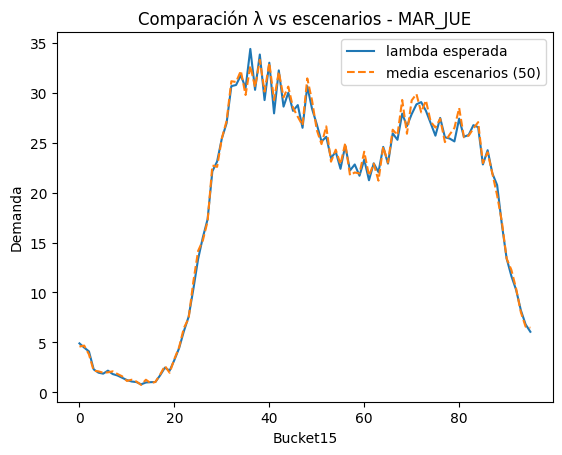

In [78]:
grupo_test = "MAR_JUE"
S = 50

escenarios_test = generar_escenarios_grupo_poisson(grupo_test, S=S, random_state=0)
print("Shape escenarios:", escenarios_test.shape)
print("Mínimo en escenarios:", escenarios_test.min())
print("Máximo en escenarios:", escenarios_test.max())

lambda_g = demanda_esperada_grupo(grupo_test)
mean_esc = escenarios_test.mean(axis=0)

diff = mean_esc - lambda_g
print("\nDiferencias promedio escenario - lambda:")
print("  min:", diff.min(), "max:", diff.max(), "mean:", diff.mean())

plt.plot(lambda_g, label="lambda esperada")
plt.plot(mean_esc, label=f"media escenarios ({S})", linestyle="--")
plt.legend()
plt.xlabel("Bucket15")
plt.ylabel("Demanda")
plt.title(f"Comparación λ vs escenarios - {grupo_test}")
plt.show()


In [81]:
# Parámetros que vienen del Excel "Datos base"
FLEET_MAX = 300           # número de vehículos
V_KMH = 25                # velocidad promedio [km/h]
AUTONOMY_KM = 350         # autonomía por carga [km]
RECHARGE_TIME_MIN = 110   # tiempo de recarga

REVENUE_FIXED = 5.5       # US$ fijo por viaje
REVENUE_PER_KM = 3.7      # US$ por km
RELOC_MARKUP = 1.25       # +25% sobre el ingreso de un viaje


In [82]:
import pandas as pd
import numpy as np

df_all = pd.read_parquet("df_all_procesado.parquet")

df_all["pickup_datetime"] = pd.to_datetime(df_all["pickup_datetime"])
df_all["dropOff_datetime"] = pd.to_datetime(df_all["dropOff_datetime"])

# Duración del viaje en minutos
df_all["trip_time_min"] = (df_all["dropOff_datetime"] - df_all["pickup_datetime"]).dt.total_seconds() / 60

# Nos quedamos con viajes razonables: entre 2 y 60 min
mask = df_all["trip_time_min"].between(2, 60)
dur_mean_min = df_all.loc[mask, "trip_time_min"].mean()
dur_mean_h = dur_mean_min / 60

# Distancia promedio del viaje usando la velocidad del Excel
avg_trip_km = dur_mean_h * V_KMH
avg_trip_km


np.float64(8.260082926570158)

In [83]:
# Ingreso promedio de un viaje de distancia promedio avg_trip_km
REV_PER_TRIP = REVENUE_FIXED + REVENUE_PER_KM * avg_trip_km

# Costo de una reubicación (oportunidad +25%)
RELOC_COST_PER_RELOC = RELOC_MARKUP * REV_PER_TRIP
REV_PER_TRIP, RELOC_COST_PER_RELOC


(np.float64(36.06230682830959), np.float64(45.07788353538699))

In [84]:
serv_por_veh_time = 15 / dur_mean_min


In [85]:
serv_por_veh_autonomy = AUTONOMY_KM / (avg_trip_km * 96)


In [86]:
SERVICIOS_POR_VEHICULO = min(serv_por_veh_time, serv_por_veh_autonomy)
SERVICIOS_POR_VEHICULO


np.float64(0.4413797495429257)

In [87]:
PENAL_NO_SERV = REV_PER_TRIP  # por ejemplo, perder 1 ingreso promedio por viaje no atendido


In [88]:
def evaluar_solucion(x: np.ndarray,
                     escenarios: np.ndarray,
                     fleet_max: int = FLEET_MAX,
                     servicios_por_vehiculo: float = SERVICIOS_POR_VEHICULO,
                     rev_por_viaje: float = REV_PER_TRIP,
                     reloc_cost_per_reloc: float = RELOC_COST_PER_RELOC,
                     penalizacion_no_servido: float = PENAL_NO_SERV) -> float:
    """
    x: vector de largo 96 con nº de vehículos por bucket15.
    escenarios: matriz S x 96 con demanda de viajes por bucket.

    Retorna un "costo" a minimizar: - beneficio esperado.
    """
    x = np.array(x, dtype=float)
    x = np.clip(x, 0, fleet_max)

    S, T = escenarios.shape
    assert T == len(x), "x y escenarios deben tener el mismo nº de buckets"

    # Capacidad de servicio por bucket (viajes máximos)
    capacidades = x * servicios_por_vehiculo  # vector T

    beneficios_esc = []

    # Costo de reubicación: cada incremento positivo en x implica una reubicación
    delta_veh = np.maximum(np.diff(x), 0)  # T-1
    n_reloc_total = delta_veh.sum()
    costo_reubic = float(n_reloc_total * reloc_cost_per_reloc)

    for s in range(S):
        demanda = escenarios[s]            # vector T
        servidos = np.minimum(demanda, capacidades)
        no_serv  = demanda - servidos

        n_serv = servidos.sum()
        n_no_serv = no_serv.sum()

        ingresos = n_serv * rev_por_viaje
        penal_ns = n_no_serv * penalizacion_no_servido

        beneficio = ingresos - penal_ns - costo_reubic
        beneficios_esc.append(beneficio)

    beneficio_esp = float(np.mean(beneficios_esc))

    # Como SA minimiza, devolvemos el negativo del beneficio esperado
    return -beneficio_esp


In [89]:
def simulated_annealing(x0: np.ndarray,
                        escenarios: np.ndarray,
                        n_iter: int = 2000,
                        T0: float = 100.0,
                        alpha: float = 0.995,
                        random_state=None,
                        **eval_kwargs):
    rng = np.random.default_rng(random_state)

    x_current = np.clip(x0.astype(int), 0, FLEET_MAX)
    f_current = evaluar_solucion(x_current, escenarios, **eval_kwargs)

    x_best = x_current.copy()
    f_best = f_current

    T = T0

    for k in range(n_iter):
        # Vecino: sumar/restar 1 vehículo en un bucket al azar
        x_new = x_current.copy()
        t = rng.integers(len(x_new))
        delta = rng.choice([-1, 1])
        x_new[t] = np.clip(x_new[t] + delta, 0, FLEET_MAX)

        f_new = evaluar_solucion(x_new, escenarios, **eval_kwargs)

        if (f_new < f_current) or (rng.random() < np.exp((f_current - f_new) / T)):
            x_current, f_current = x_new, f_new
            if f_new < f_best:
                x_best, f_best = x_new, f_new

        T *= alpha

    return x_best, f_best


In [90]:
# Escenarios para día tipo MAR_JUE (modelo de demanda que ya construimos)
S = 50
escenarios_MJ = generar_escenarios_grupo_poisson("MAR_JUE", S=S, random_state=42)

T = escenarios_MJ.shape[1]  # 96
x0 = np.full(T, 150, dtype=int)  # solución inicial: 150 autos todo el día

x_opt, f_opt = simulated_annealing(
    x0=x0,
    escenarios=escenarios_MJ,
    n_iter=3000,
    T0=100.0,
    alpha=0.995,
    random_state=0
)

x_opt, f_opt


(array([150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150,
        150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150,
        150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150,
        150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150,
        150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150,
        150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150,
        150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150,
        150, 150, 150, 150, 150]),
 -66229.8689824637)

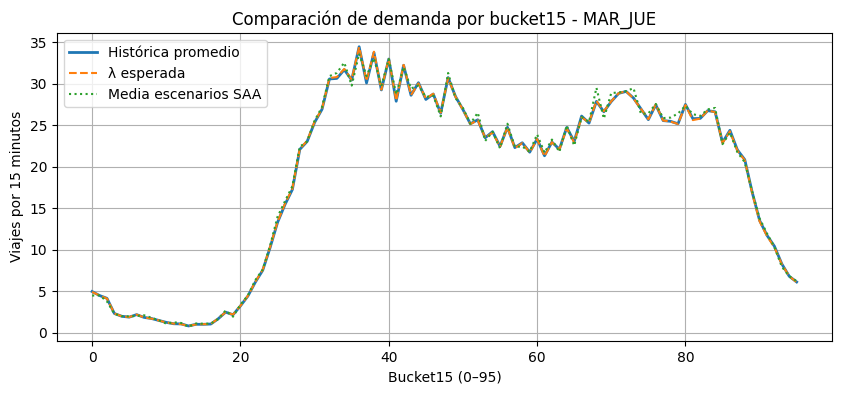

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

grupo_test = "MAR_JUE"

# 1) Demanda histórica promedio por bucket (días normales de ese grupo)
daily_profiles_fino_df = daily_profiles_fino.reset_index()

hist_grupo = (
    daily_profiles_fino_df[
        daily_profiles_fino_df["tipo_dia_fino"] == grupo_test
    ][bucket_cols]
    .mean()
    .values
)

# 2) λ esperada por bucket (lo que construimos con el modelo)
lambda_g = lambda_15_fino[grupo_test]

# 3) Media de escenarios generados con SAA
escenarios_g = generar_escenarios_grupo_poisson(grupo_test, S=100, random_state=0)
mean_esc = escenarios_g.mean(axis=0)

# Plot comparación
plt.figure(figsize=(10, 4))
plt.plot(hist_grupo, label="Histórica promedio", linewidth=2)
plt.plot(lambda_g, label="λ esperada", linestyle="--")
plt.plot(mean_esc, label="Media escenarios SAA", linestyle=":")
plt.xlabel("Bucket15 (0–95)")
plt.ylabel("Viajes por 15 minutos")
plt.title(f"Comparación de demanda por bucket15 - {grupo_test}")
plt.legend()
plt.grid(True)
plt.show()


In [96]:
# Política de flota por bucket: 150 autos todo el día
T = escenarios_g.shape[1]        # 96
x = np.full(T, 150)              # perfil plano

# Capacidad por bucket (viajes que podemos servir en cada 15 min)
capacidad = x * SERVICIOS_POR_VEHICULO  # vector de largo 96

# Media de demanda por bucket en los escenarios
demanda_media = escenarios_g.mean(axis=0)

# Nivel de servicio por bucket:
# proporción de escenarios en que la demanda del bucket se cubre completamente
nivel_servicio = (escenarios_g <= capacidad).mean(axis=0)  # promedio por columna

# Tabla resumen por bucket
df_15 = pd.DataFrame({
    "bucket15": np.arange(T),
    "demanda_media": demanda_media,
    "capacidad": capacidad,
    "nivel_servicio": nivel_servicio
})

df_15.head(20)  # primeras 20 filas


,bucket15,demanda_media,capacidad,nivel_servicio
0,0,4.46,66.206962,1.0
1,1,4.49,66.206962,1.0
2,2,3.76,66.206962,1.0
3,3,2.27,66.206962,1.0
4,4,1.98,66.206962,1.0
5,5,1.95,66.206962,1.0
6,6,2.01,66.206962,1.0
7,7,2.09,66.206962,1.0
8,8,1.79,66.206962,1.0
9,9,1.48,66.206962,1.0


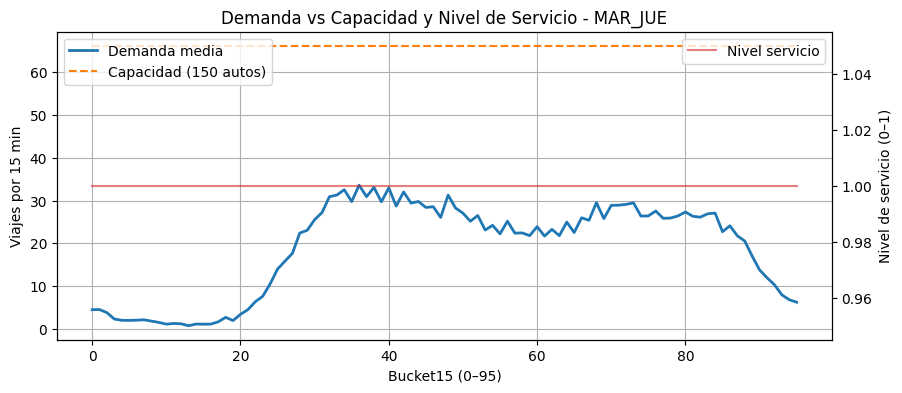

In [97]:
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(demanda_media, label="Demanda media", linewidth=2)
ax1.plot(capacidad, label="Capacidad (150 autos)", linestyle="--")
ax1.set_xlabel("Bucket15 (0–95)")
ax1.set_ylabel("Viajes por 15 min")
ax1.legend(loc="upper left")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(nivel_servicio, label="Nivel servicio", color="tab:red", alpha=0.6)
ax2.set_ylabel("Nivel de servicio (0–1)")
ax2.legend(loc="upper right")

plt.title(f"Demanda vs Capacidad y Nivel de Servicio - {grupo_test}")
plt.show()


Zonal

In [101]:
import pandas as pd
import numpy as np

# Asegurar datetime
df_normal["pickup_datetime"] = pd.to_datetime(df_normal["pickup_datetime"])

# Extraer fecha, weekday y bucket15
df_normal["date"]    = df_normal["pickup_datetime"].dt.date
df_normal["weekday"] = df_normal["pickup_datetime"].dt.weekday
df_normal["hour"]    = df_normal["pickup_datetime"].dt.hour
df_normal["minute"]  = df_normal["pickup_datetime"].dt.minute
df_normal["bucket15"] = df_normal["hour"] * 4 + (df_normal["minute"] // 15)

# Tipo de día (LUN, MAR_JUE, etc.)
df_normal["tipo_dia_fino"] = df_normal["weekday"].map(grupo_weekday)

df_normal[["pickup_datetime", "date", "weekday", "tipo_dia_fino", "PUlocationID", "bucket15"]].head()


,pickup_datetime,date,weekday,tipo_dia_fino,PUlocationID,bucket15
2176,2025-01-03 00:00:56,2025-01-03,4,VIERNES,161.0,0
2177,2025-01-03 00:03:36,2025-01-03,4,VIERNES,170.0,0
2178,2025-01-03 00:05:17,2025-01-03,4,VIERNES,127.0,0
2179,2025-01-03 00:08:43,2025-01-03,4,VIERNES,148.0,0
2180,2025-01-03 00:12:42,2025-01-03,4,VIERNES,48.0,0


In [102]:
# número de viajes por (tipo_dia_fino, date, zona, bucket15)
demanda_zonal = (
    df_normal
    .groupby(["tipo_dia_fino", "date", "PUlocationID", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

demanda_zonal.head()


,tipo_dia_fino,date,PUlocationID,bucket15,viajes
0,DOMINGO,2025-01-05,4.0,4,1
1,DOMINGO,2025-01-05,4.0,21,1
2,DOMINGO,2025-01-05,4.0,42,1
3,DOMINGO,2025-01-05,4.0,48,1
4,DOMINGO,2025-01-05,4.0,49,1


In [103]:
lambda_zonal = (
    demanda_zonal
    .groupby(["tipo_dia_fino", "PUlocationID", "bucket15"])["viajes"]
    .mean()
    .reset_index(name="lambda_gzt")
)

lambda_zonal.head()


,tipo_dia_fino,PUlocationID,bucket15,lambda_gzt
0,DOMINGO,4.0,1,1.00
1,DOMINGO,4.0,3,1.00
2,DOMINGO,4.0,4,1.00
3,DOMINGO,4.0,5,1.25
4,DOMINGO,4.0,6,1.00


In [104]:
# Matriz: index = (tipo_dia_fino, PUlocationID), columns = bucket15
lambda_zonal_mat = lambda_zonal.pivot_table(
    index=["tipo_dia_fino", "PUlocationID"],
    columns="bucket15",
    values="lambda_gzt",
    fill_value=0.0
)

lambda_zonal_mat.head()


bucket15                     0    1    2    3    4     5    6    7    8    9   \
tipo_dia_fino PUlocationID                                                      
DOMINGO       4.0           0.0  1.0  0.0  1.0  1.0  1.25  1.0  0.0  1.0  1.0   
              12.0          0.0  0.0  0.0  0.0  0.0  0.00  0.0  0.0  0.0  0.0   
              13.0          0.0  0.0  0.0  0.0  0.0  1.00  0.0  0.0  0.0  0.0   
              24.0          0.0  0.0  0.0  0.0  1.0  0.00  1.0  0.0  0.0  0.0   
              41.0          1.0  1.0  1.0  1.5  0.0  0.00  2.0  0.0  0.0  0.0   

bucket15                    ...   86   87   88   89   90   91   92   93   94  \
tipo_dia_fino PUlocationID  ...                                                
DOMINGO       4.0           ...  1.0  1.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0   
              12.0          ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
              13.0          ...  1.0  1.0  1.0  0.0  1.0  0.0  0.0  0.0  0.0   
              24.0          ...  1.0  1.0  0.0  0.0  0.0  1.0  1.0  1.0  0.0   
              41.0          ...  0.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0   

bucket15                     95  
tipo_dia_fino PUlocationID       
DOMINGO       4.0           0.0  
              12.0          0.0  
              13.0          0.0  
              24.0          0.0  
              41.0          0.0  

[5 rows x 96 columns]

In [106]:
from numpy.random import default_rng

def generar_escenarios_zonal(tipo_dia_fino: str,
                             S: int = 50,
                             random_state=None):
    """
    Genera S escenarios de demanda zonal para un tipo de día (LUN, MAR_JUE, etc.)

    Retorna:
      zonas: lista de PUlocationID en ese tipo de día
      buckets: lista de bucket15 (0..95)
      escenarios: array de shape (S, n_zonas, T)
                  donde escenarios[s, i, t] = demanda de la zona i en bucket t en el escenario s
    """
    rng = default_rng(random_state)

    # Submatriz para el tipo de día g
    sub = lambda_zonal_mat.loc[tipo_dia_fino]   # index = PUlocationID, columns = bucket15

    zonas = sub.index.to_list()
    buckets = sub.columns.to_list()

    lambdas = sub.values.astype(float)  # shape (n_zonas, T)
    n_zonas, T = lambdas.shape

    # Escenarios Poisson independientes
    # shape final: (S, n_zonas, T)
    escenarios = rng.poisson(lambdas[None, :, :], size=(S, n_zonas, T))

    return zonas, buckets, escenarios


In [107]:
zonas_MJ, buckets_MJ, escenarios_MJ = generar_escenarios_zonal("MAR_JUE", S=50, random_state=0)

print("N zonas MAR_JUE:", len(zonas_MJ))
print("Buckets:", len(buckets_MJ))
print("Shape escenarios_MJ:", escenarios_MJ.shape)  # (50, n_zonas, 96)


N zonas MAR_JUE: 66
Buckets: 96
Shape escenarios_MJ: (50, 66, 96)


In [108]:
# media de escenarios por zona y bucket
mean_esc_MJ = escenarios_MJ.mean(axis=0)  # shape (n_zonas, T)

# lambda de referencia
lambda_MJ = lambda_zonal_mat.loc["MAR_JUE"].values  # misma shape

diff = mean_esc_MJ - lambda_MJ
print("Diff media escenarios - λ (MAR_JUE):")
print("  min:", diff.min(), "max:", diff.max(), "mean:", diff.mean())


Diff media escenarios - λ (MAR_JUE):
  min: -0.6616216216216217 max: 0.7021052631578948 mean: 0.001120303411827142


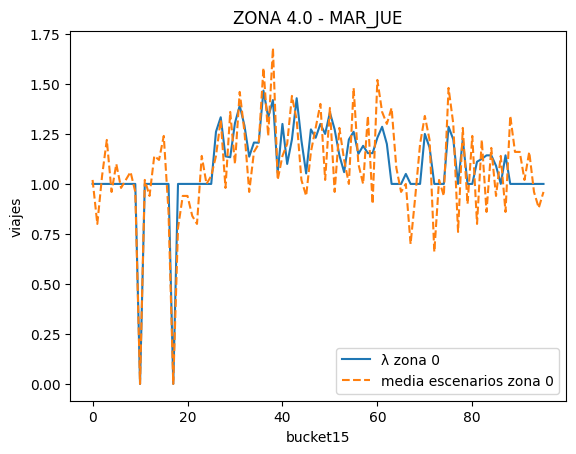

In [109]:
i0 = 0
import matplotlib.pyplot as plt

plt.plot(lambda_MJ[i0], label="λ zona 0")
plt.plot(mean_esc_MJ[i0], label="media escenarios zona 0", linestyle="--")
plt.legend()
plt.xlabel("bucket15")
plt.ylabel("viajes")
plt.title(f"ZONA {zonas_MJ[i0]} - MAR_JUE")
plt.show()


In [110]:
# Guardar λ y escenarios para uso en Gurobi
lambda_zonal_mat.to_csv("lambda_zonal_mat.csv")  # forecast
# Escenarios de un tipo de día (ejemplo MAR_JUE)
np.save("escenarios_MAR_JUE.npy", escenarios_MJ)
np.save("zonas_MAR_JUE.npy", np.array(zonas_MJ))
np.save("buckets_MAR_JUE.npy", np.array(buckets_MJ))


Como incorporarlo en Gurobi

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np

# Cargar λ zonal desde el CSV
lambda_df = pd.read_csv("lambda_zonal_mat.csv", index_col=[0, 1])
# index: (tipo_dia_fino, PUlocationID), columns: bucket15

# Elige el tipo de día que quieres modelar, por ejemplo "MAR_JUE"
tipo = "MAR_JUE"

# Submatriz de λ para ese tipo de día
lambda_g = lambda_df.xs(tipo, level=0)        # index = PUlocationID, columns = bucket15

# Conjuntos de zonas y tiempos
ZONAS   = list(lambda_g.index)                # lista de PUlocationID
BUCKETS = list(lambda_g.columns.astype(int))  # [0, 1, ..., 95]

# Parámetro de demanda determinista: d[i,t] = λ_{tipo, i, t}
demand = {(i, t): float(lambda_g.loc[i, t]) for i in ZONAS for t in BUCKETS}
